In [1]:
import json
import os

# Load all files
data_dir = "../data/raw/"
all_data = []

for file in os.listdir(data_dir):
    if file.endswith(".json"):
        with open(os.path.join(data_dir, file)) as f:
            all_data.append(json.load(f))

# Quick peek
for person in all_data:
    print(f"User: {person['username']}")
    print(f"Attempts: {len(person['attempts'])}")
    print(f"Sample mean dwell: {person['attempts'][0]['features']['mean_dwell']:.2f} ms")
    print(f"Sample mean flight: {person['attempts'][0]['features']['mean_flight']:.2f} ms")
    print("---")

User: Diya
Attempts: 15
Sample mean dwell: 79.15 ms
Sample mean flight: 242.55 ms
---
User: Jash
Attempts: 15
Sample mean dwell: 81.23 ms
Sample mean flight: 286.18 ms
---
User: rugvedd
Attempts: 15
Sample mean dwell: 91.12 ms
Sample mean flight: 130.00 ms
---


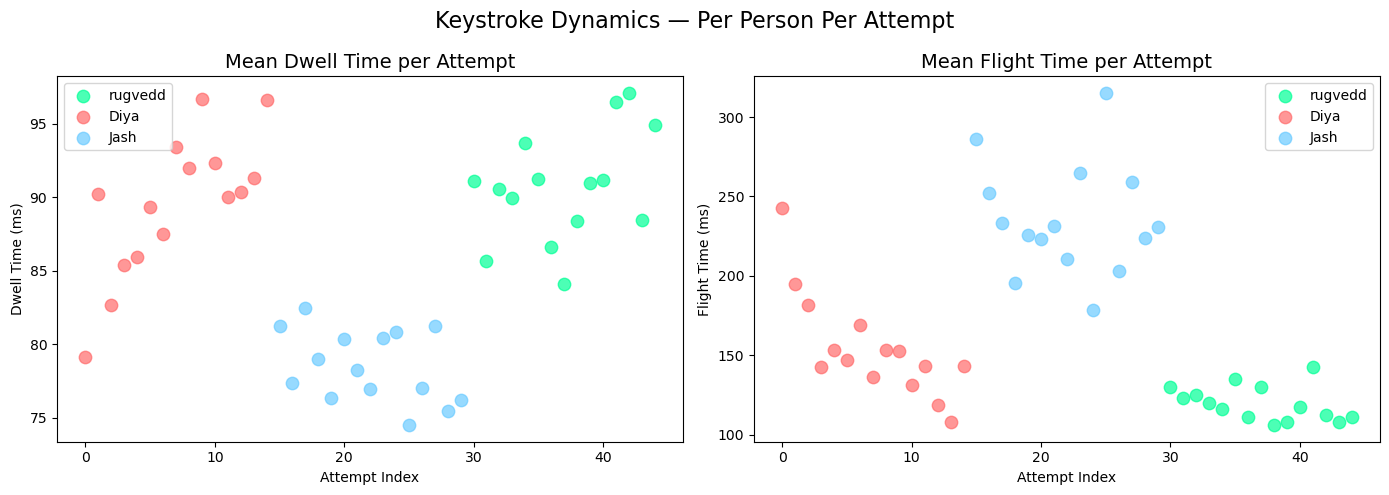

In [2]:
import matplotlib.pyplot as plt
import numpy as np

users = []
dwell_per_attempt = []
flight_per_attempt = []

for person in all_data:
    name = person['username']
    for attempt in person['attempts']:
        users.append(name)
        dwell_per_attempt.append(attempt['features']['mean_dwell'])
        flight_per_attempt.append(attempt['features']['mean_flight'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get unique users and assign colors
unique_users = list(set(users))
colors = ['#00ff96', '#ff6b6b', '#6bcbff']
color_map = {u: colors[i] for i, u in enumerate(unique_users)}

for user in unique_users:
    indices = [i for i, u in enumerate(users) if u == user]
    
    axes[0].scatter(
        [i for i in indices],
        [dwell_per_attempt[i] for i in indices],
        label=user, color=color_map[user], alpha=0.7, s=80
    )
    axes[1].scatter(
        [i for i in indices],
        [flight_per_attempt[i] for i in indices],
        label=user, color=color_map[user], alpha=0.7, s=80
    )

axes[0].set_title("Mean Dwell Time per Attempt", fontsize=14)
axes[0].set_ylabel("Dwell Time (ms)")
axes[0].set_xlabel("Attempt Index")
axes[0].legend()

axes[1].set_title("Mean Flight Time per Attempt", fontsize=14)
axes[1].set_ylabel("Flight Time (ms)")
axes[1].set_xlabel("Attempt Index")
axes[1].legend()

plt.suptitle("Keystroke Dynamics — Per Person Per Attempt", fontsize=16)
plt.tight_layout()
plt.savefig("../data/eda_scatter.png", dpi=150)
plt.show()

## Finding 1
Flight time is a stronger discriminating feature than dwell time.
Rugved shows significantly lower and more consistent flight times (~110ms) 
compared to Jash (~230ms), suggesting typing speed rhythm is 
highly person-specific and stable across attempts.

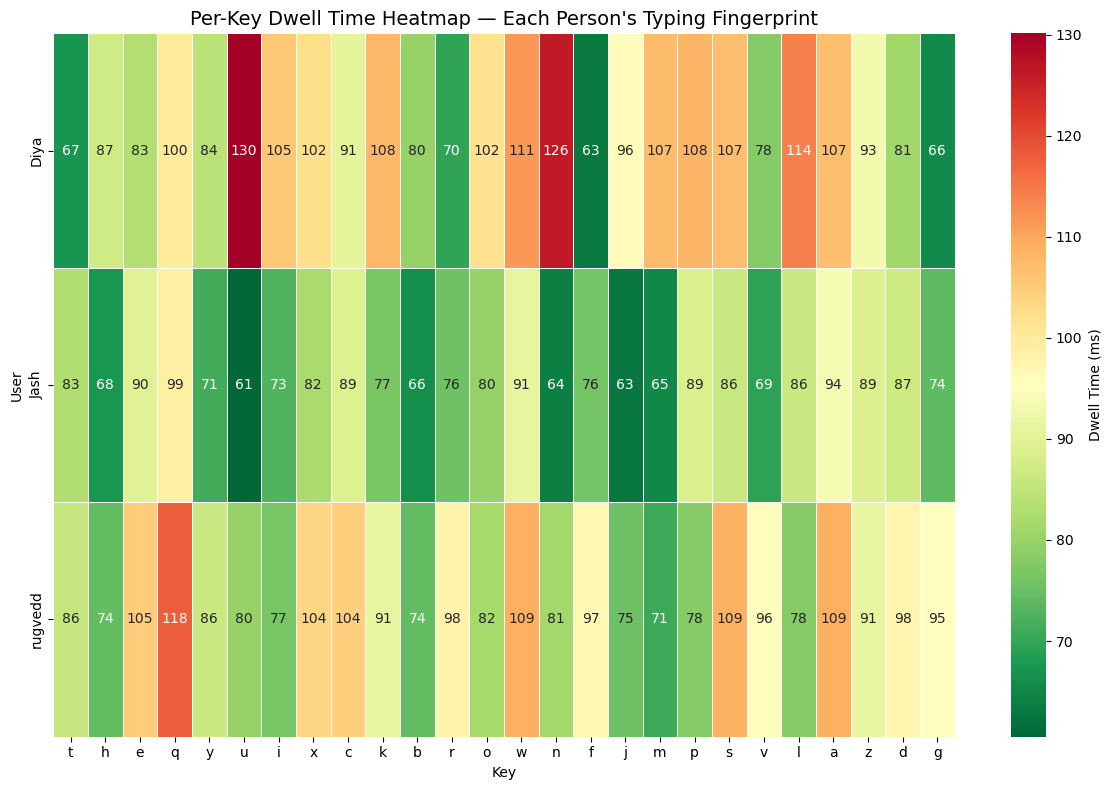

In [3]:
import pandas as pd
import seaborn as sns

# Build per-key dwell matrix for each user
key_dwell_data = {}

for person in all_data:
    name = person['username']
    key_dwells = {}
    
    for attempt in person['attempts']:
        for key, dwell in attempt['features']['dwell_per_key'].items():
            if key not in key_dwells:
                key_dwells[key] = []
            key_dwells[key].append(dwell)
    
    # Average dwell per key
    key_dwell_data[name] = {k: np.mean(v) for k, v in key_dwells.items()}

# Convert to DataFrame
df = pd.DataFrame(key_dwell_data).fillna(0)

# Only keep common letter keys for clean visualization
common_keys = [k for k in df.index if len(k) == 1 and k.isalpha()]
df = df.loc[common_keys]

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.T,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Dwell Time (ms)'}
)
plt.title("Per-Key Dwell Time Heatmap — Each Person's Typing Fingerprint", fontsize=14)
plt.xlabel("Key")
plt.ylabel("User")
plt.tight_layout()
plt.savefig("../data/dwell_heatmap.png", dpi=150)
plt.show()

## Finding 2 — The Typing Fingerprint
Per-key dwell time patterns are unique to each individual.
The 'q' key alone shows a 2x difference between users (61ms vs 130ms).
Even without any model, the heatmap visually separates all 3 users completely.
This confirms that keystroke dynamics carry strong biometric signal.